# Import các thư viện cần thiết


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path
from tqdm import tqdm
from typing import Dict

# Phân tích thời lượng (giây) của các video ngắn

Xác định thời lượng thực tế của các video


In [2]:
def get_video_duration(filename: str) -> float:
    """
    Ref: https://stackoverflow.com/questions/3844430/how-do-i-get-the-duration-of-a-video-in-python
    """
    result = subprocess.run(["ffprobe", "-v", "error", "-show_entries",
                             "format=duration", "-of",
                             "default=noprint_wrappers=1:nokey=1", filename],
                            stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT)
    return float(result.stdout)


# Danh sách các video .avi trong MSVD dataset
video_paths = list(Path("data/raw/MSRVTT/raw_video/").glob("*.mp4"))
assert len(video_paths) == 10_000

# Xác định thời lượng thực tế của các video
print("Getting video durations...")
durations: Dict[str, float] = {}
for video_path in tqdm(video_paths):
    durations[video_path.stem] = get_video_duration(str(video_path))

Getting video durations...


100%|██████████| 10000/10000 [09:58<00:00, 16.71it/s]


Tạo DataFrame thể hiện thời lượng thực tế và thời lượng theo lý thuyết của các video


In [3]:
duration_df = pd.DataFrame(durations.items(), columns=["video_id", "duration"])
duration_df.to_csv("./MSRVTT_video_durations.csv", index=False)

In [4]:
duration_df = pd.read_csv("./MSRVTT_video_durations.csv")
duration_df.head()

,video_id,duration
0,video0,12.000000
1,video1,22.007302
2,video10,13.000000
3,video100,10.010000
4,video1000,11.000000


In [5]:
duration_df["duration"].describe()

count    10000.000000
mean        14.862298
std          5.071187
min          9.581995
25%         11.011000
50%         13.012177
75%         17.017000
max         30.030030
Name: duration, dtype: float64

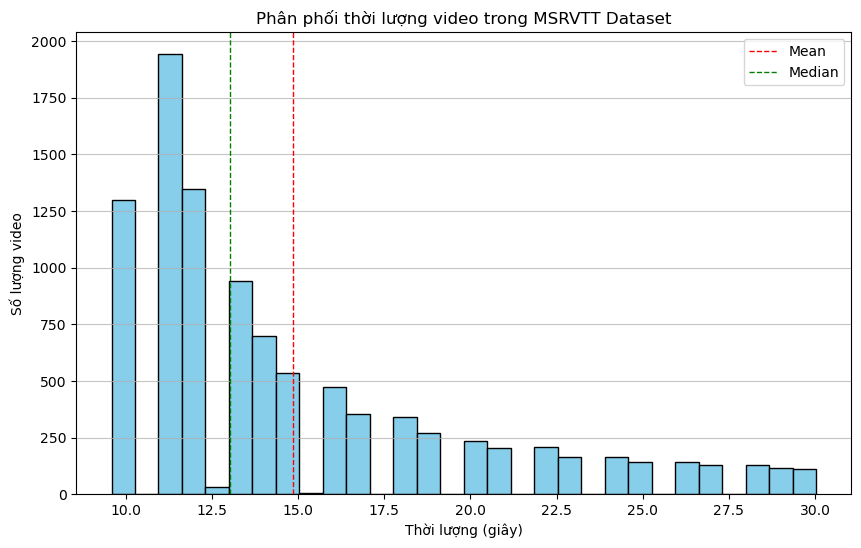

In [9]:
# Vẽ biểu đồ phân phối thời lượng video
plt.figure(figsize=(10, 6))
plt.hist(duration_df["duration"], bins=30, color='skyblue', edgecolor='black')
plt.axvline(duration_df["duration"].mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(duration_df["duration"].median(), color='green', linestyle='dashed', linewidth=1)
plt.legend({'Mean':duration_df["duration"].mean(),'Median':duration_df["duration"].median()})
plt.title("Phân phối thời lượng video trong MSRVTT Dataset")
plt.xlabel("Thời lượng (giây)")
plt.ylabel("Số lượng video")
plt.grid(axis='y', alpha=0.75)
plt.show()

# Phân tích độ dài caption của các video ngắn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
captions = []

for split in ["train", "val", "test"]:
    with open(f"./data/MSRVTT/metadata/{split}.json", "r") as f:
        data = json.load(f)
        for video_id, item in data.items():
            for _, caption in item.items():
                captions.append(caption)

assert len(captions) == 200_000

In [3]:
# In random 5 caption để kiểm tra
import random
for _ in range(5):
    print(random.choice(captions))

a person is smiling and speaking about something and his friend also is smiling suddenly
some guys spinning around head down on a bat
city details being displayed on electronic jumbo tron
a woman holding a yellow scarf
a man is talking about a map and politics


In [4]:
caption_ser = pd.Series(captions)
caption_lengths = caption_ser.str.len()
caption_lengths.describe()

count    200000.000000
mean         47.876750
std          22.273707
min           7.000000
25%          32.000000
50%          43.000000
75%          58.000000
max         367.000000
dtype: float64

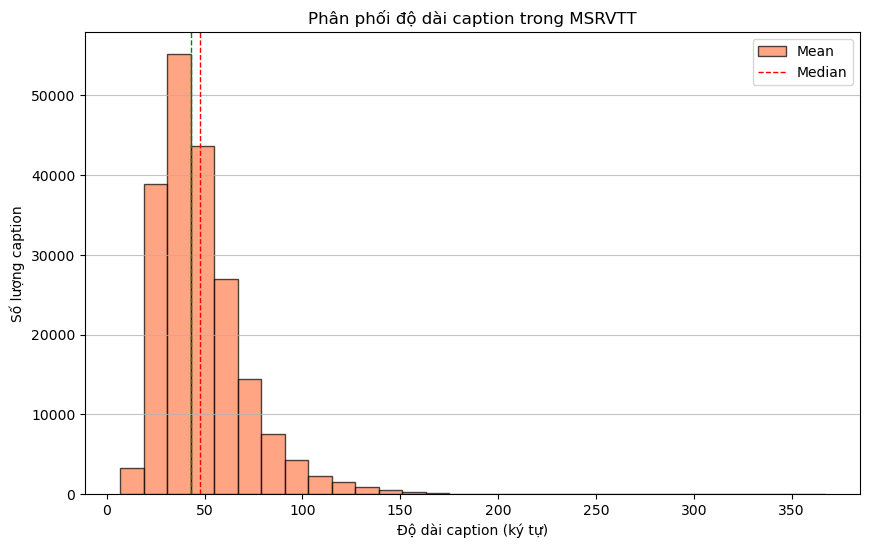

In [5]:
caption_lengths.plot.hist(bins=30, color='coral', alpha=0.7, edgecolor='black', figsize=(10, 6))
plt.axvline(caption_lengths.mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(caption_lengths.median(), color='green', linestyle='dashed', linewidth=1)
plt.legend({'Mean': caption_lengths.mean(), 'Median': caption_lengths.median()})
plt.title("Phân phối độ dài caption trong MSRVTT")
plt.xlabel("Độ dài caption (ký tự)")
plt.ylabel("Số lượng caption")
plt.grid(axis='y', alpha=0.75)
plt.show()

# Split features into train, val, test sets based on video IDs


In [2]:
import h5py
import numpy as np
import pandas as pd
import json
from tqdm import tqdm

# === Load the train, validation, and test video id ===
with open("./data/MSRVTT/metadata/train.json", "r") as f:
    train_data = json.load(f)
    train_video_ids = set(train_data.keys())
    assert len(train_video_ids) == 6513
with open("./data/MSRVTT/metadata/val.json", "r") as f:
    val_data = json.load(f)
    val_video_ids = set(val_data.keys())
    assert len(val_video_ids) == 497
with open("./data/MSRVTT/metadata/test.json", "r") as f:
    test_data = json.load(f)
    test_video_ids = set(test_data.keys())
    assert len(test_video_ids) == 2990

# === Define the feature type and paths ===
corpus = "MSRVTT"
# feature_type = "newBlip2ClsKF"
# feature_type = "newMViTv2"
feature_type = "newImgCapBlip2KF"
total_feature_path = f"./data/{corpus}/features/{corpus}_{feature_type}.hdf5"
train_feature_path = f"./data/{corpus}/features/{corpus}_{feature_type}_train.hdf5"
val_feature_path = f"./data/{corpus}/features/{corpus}_{feature_type}_val.hdf5"
test_feature_path = f"./data/{corpus}/features/{corpus}_{feature_type}_test.hdf5"

train_features = {}
test_features = {}
val_features = {}

# Split the features into train, validation, and test sets
#   based on the video IDs in the respective DataFrames
print("Splitting features into train, validation, and test sets...")
with h5py.File(total_feature_path, "r") as f:
    assert len(f.keys()) == 10_000
    for key in tqdm(f.keys(), desc="Splitting features"):
        assert len(f[key].shape) == 2
        if key in train_video_ids:
            train_features[key] = f[key][:]
        elif key in val_video_ids:
            val_features[key] = f[key][:]
        elif key in test_video_ids:
            test_features[key] = f[key][:]
        else:
            raise ValueError(f"Unexpected video ID: {key}")

with h5py.File(train_feature_path, "w") as f:
    for key, value in train_features.items():
        f.create_dataset(key, data=value)
with h5py.File(val_feature_path, "w") as f:
    for key, value in val_features.items():
        f.create_dataset(key, data=value)
with h5py.File(test_feature_path, "w") as f:
    for key, value in test_features.items():
        f.create_dataset(key, data=value)

# Verify the splits
with h5py.File(train_feature_path, "r") as f:
    print(f"Number of training videos: {len(f.keys())}")
with h5py.File(val_feature_path, "r") as f:
    print(f"Number of validation videos: {len(f.keys())}")
with h5py.File(test_feature_path, "r") as f:
    print(f"Number of test videos: {len(f.keys())}")

Splitting features into train, validation, and test sets...


Splitting features: 100%|██████████| 10000/10000 [00:16<00:00, 607.74it/s]


Number of training videos: 6513
Number of validation videos: 497
Number of test videos: 2990


In [1]:
import pandas as pd

gop_df = pd.read_csv("./msrvtt_new_gop_counts.csv")
keyframe_df = pd.read_csv("./msrvtt_new_keyframe_counts.csv")
merged_df = pd.merge(gop_df, keyframe_df, on="video_id")
merged_df.head()

,video_id,gop_count,keyframe_count
0,video0,9,9
1,video1,15,15
2,video10,10,10
3,video100,9,9
4,video1000,8,8


In [2]:
(merged_df["gop_count"] == merged_df["keyframe_count"]).sum()

10000

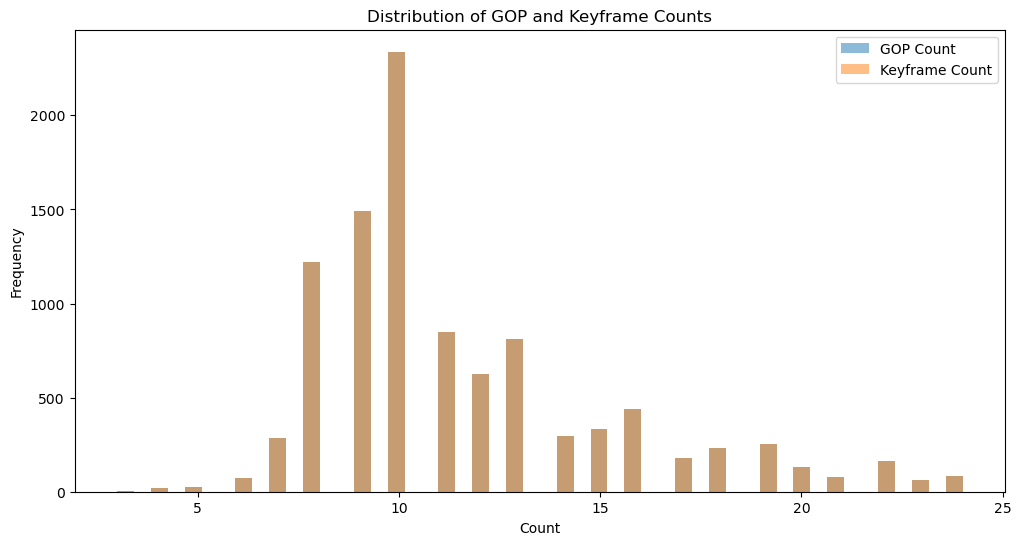

In [6]:
# Plot the distribution of GOP and keyframe counts
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(merged_df["gop_count"], bins=50, alpha=0.5, label="GOP Count")
plt.hist(merged_df["keyframe_count"], bins=50, alpha=0.5, label="Keyframe Count")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Distribution of GOP and Keyframe Counts")
plt.legend()
plt.show()

In [7]:
merged_df.describe()

,gop_count,keyframe_count
count,10000.000000,10000.000000
mean,11.619500,11.619500
std,3.773585,3.773585
min,3.000000,3.000000
25%,9.000000,9.000000
50%,10.000000,10.000000
75%,13.000000,13.000000
max,24.000000,24.000000


- #GOP in training set:

In [3]:
import pandas as pd
import json

with open("../data/MSRVTT/metadata/train.json", "r") as f:
    train_data = json.load(f)
    train_video_ids = set(train_data.keys())
    assert len(train_video_ids) == 6513
    
df = pd.read_csv("./msrvtt_new_gop_counts.csv")
df.head()

,video_id,gop_count
0,video0,9
1,video1,15
2,video10,10
3,video100,9
4,video1000,8


In [4]:
train_df = df[df["video_id"].isin(train_video_ids)]
train_df.describe()

,gop_count
count,6513.000000
mean,11.556733
std,3.739015
min,3.000000
25%,9.000000
50%,10.000000
75%,13.000000
max,24.000000


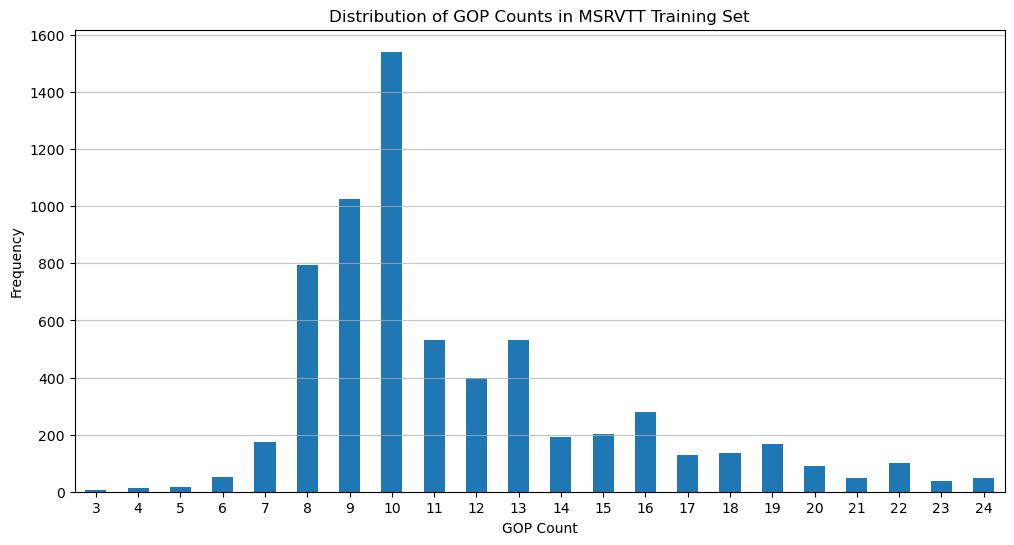

In [15]:
from matplotlib import pyplot as plt
train_df["gop_count"].value_counts().sort_index().plot(kind="bar", figsize=(12, 6))
plt.xlabel("GOP Count")
plt.ylabel("Frequency")
plt.title("Distribution of GOP Counts in MSRVTT Training Set")
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=0)
plt.show()

In [16]:
for target_gop in [8, 10, 13, 16, 19]:
    # percentile
    num_samples_low = train_df[train_df["gop_count"] <= target_gop]["gop_count"].count()
    percentile = num_samples_low / len(train_df) * 100
    print(f"Target GOP: {target_gop}, Number of samples: {num_samples_low}, Percentile: {percentile:.2f}%")

Target GOP: 8, Number of samples: 1057, Percentile: 16.23%
Target GOP: 10, Number of samples: 3623, Percentile: 55.63%
Target GOP: 13, Number of samples: 5084, Percentile: 78.06%
Target GOP: 16, Number of samples: 5756, Percentile: 88.38%
Target GOP: 19, Number of samples: 6185, Percentile: 94.96%


In [17]:
train_df["gop_count"].quantile([0.25, 0.50, 0.75, 0.85, 0.95])

0.25     9.0
0.50    10.0
0.75    13.0
0.85    16.0
0.95    20.0
Name: gop_count, dtype: float64

In [2]:
s = "a"
s.split("+")

['a']

In [7]:
import torch
import torch.nn as nn

s = nn.Embedding(3, 512)
s = nn.LayerNorm(512)
# Number of parameters
num_params = sum(p.numel() for p in s.parameters())
print(f"Number of parameters in the embedding layer: {num_params}")

Number of parameters in the embedding layer: 1024


# Phân tích số lượng keyframe (I-frame) trong các video ngắn


In [2]:
import av
import os

# Mở file video
container = av.open('./data/raw/MSRVTT/raw_video/video0.mp4')

print("Bắt đầu trích xuất I-frame...")
frame_count = 0
imgs = []
# Lặp qua các frame trong stream video
# Chúng ta decode stream video chính (thường là stream 0)
for frame in container.decode(video=0):
    
    # Kiểm tra cờ frame.key_frame
    # I-frame sẽ có cờ này là True
    if frame.key_frame:
        frame_count += 1
        print(f"Phát hiện I-frame tại PTS: {frame.pts}")
        
        # Lưu frame thành file ảnh (ví dụ: PNG)
        img = frame.to_image() # Chuyển đổi thành PIL Image
        print(img)
        imgs.append(img)
        # output_filename = os.path.join(output_dir, f"keyframe-{frame_count:04d}.png")
        # img.save(output_filename)

print(f"Đã trích xuất và lưu tổng cộng {frame_count} I-frame.")
container.close()

Bắt đầu trích xuất I-frame...
Phát hiện I-frame tại PTS: 0
<PIL.Image.Image image mode=RGB size=320x240 at 0x7F17B4D97850>
Phát hiện I-frame tại PTS: 26624
<PIL.Image.Image image mode=RGB size=320x240 at 0x7F17B4D90450>
Phát hiện I-frame tại PTS: 89600
<PIL.Image.Image image mode=RGB size=320x240 at 0x7F17B4D9F9D0>
Phát hiện I-frame tại PTS: 146432
<PIL.Image.Image image mode=RGB size=320x240 at 0x7F17B4DA4150>
Đã trích xuất và lưu tổng cộng 4 I-frame.


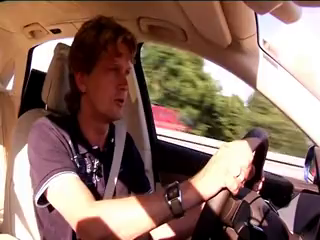

In [12]:
imgs[0]

In [ ]:
import av
from pathlib import Path
from typing import Dict
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def count_keyframes(video_path: str) -> int:
    """
    Đếm số lượng I-frame trong một video sử dụng PyAV.
    """
    container = av.open(video_path)
    keyframe_count = 0

    for frame in container.decode(video=0):
        if frame.key_frame:
            keyframe_count += 1

    container.close()
    return keyframe_count


# Danh sách các video .avi trong MSVD dataset
video_paths = list(Path("./data/raw/MSVD/raw_video/").glob("*.avi"))
assert len(video_paths) == 1970

# Đếm số lượng I-frame trong mỗi video
print("Counting keyframes in videos...")
keyframe_counts: Dict[str, int] = {}
for video_path in tqdm(video_paths):
    keyframe_counts[video_path.stem] = count_keyframes(str(video_path))

In [ ]:
keyframe_df = pd.DataFrame(keyframe_counts.items(), columns=["video_id", "keyframe_count"])
keyframe_df.to_csv("./MSVD_keyframe_counts.csv", index=False)
keyframe_df.head()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

keyframe_df = pd.read_csv("./MSRVTT_keyframe_counts.csv")
keyframe_df.head()

,video_id,keyframe_count
0,video0,4
1,video1,5
2,video10,2
3,video100,6
4,video1000,2


In [7]:
def keyframe_count_analysis(df: pd.DataFrame) -> None:
    # Tính thống kê số lượng I-frame
    count_stats = df["keyframe_count"].describe()
    print("Thống kê số lượng I-frame:")
    print(count_stats)
    
    # Vẽ biểu đồ phân phối số lượng I-frame
    plt.figure(figsize=(10, 6))
    plt.hist(df["keyframe_count"], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
    plt.axvline(df["keyframe_count"].mean(), color='red', linestyle='dashed', linewidth=1)
    plt.axvline(df["keyframe_count"].median(), color='green', linestyle='dashed', linewidth=1)
    plt.legend({'Mean': df["keyframe_count"].mean(), 'Median': df["keyframe_count"].median()})
    plt.title("Phân phối số lượng I-frame trong video")
    plt.xlabel("Số lượng I-frame")
    plt.ylabel("Số lượng video")
    plt.grid(axis='y', alpha=0.75)
    plt.show()

Thống kê số lượng I-frame:
count    10000.000000
mean         3.571600
std          1.766914
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         19.000000
Name: keyframe_count, dtype: float64


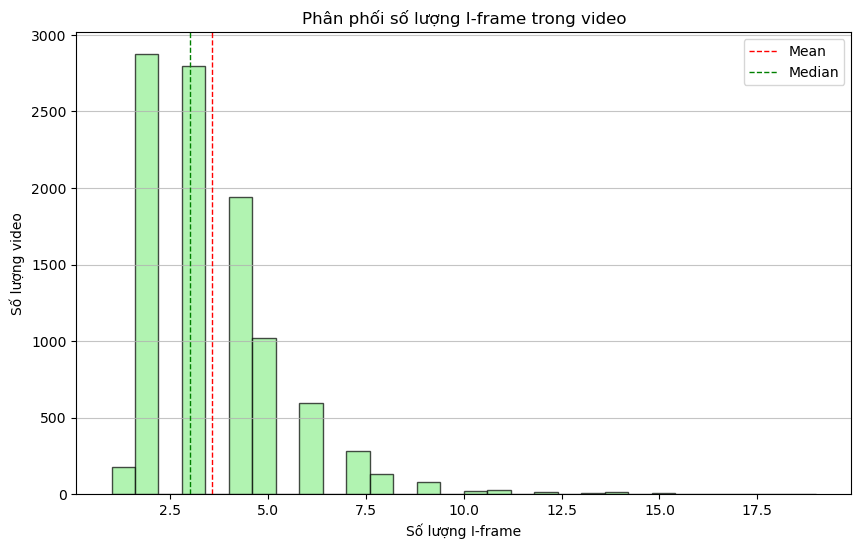

In [8]:
keyframe_count_analysis(keyframe_df)

# Xác định id của video trong các tập dữ liệu


In [ ]:
import json
import pandas as pd
import numpy as np

with open("./data/MSRVTT/metadata/test.json", "r") as f:
    data = json.load(f)
    
    _id_lst = []
    for video_id in data.keys():
        _id_lst.append(int(video_id.split("video")[-1]))
        
    for id in sorted(_id_lst):
        print(id)
        
"""
train_video_ids = set(train_data.keys())
for i in range(0, len(train_data)):
    assert f"video{i}" in train_video_ids
""";

# Vẽ biểu đồ phân phối số lượng motion group và keyframe count

In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py

motion_groups = {}
with h5py.File("./data/MSRVTT/features/MSRVTT_MViTv2.hdf5", "r") as f:
    for key in f.keys():
        motion_groups[key] = f[key][:].shape[0]

In [10]:
motion_df = pd.DataFrame(
    list(motion_groups.items()),
    columns=["video_id", "motion_group"]
)
motion_df.head()

,video_id,motion_group
0,video0,9
1,video1,17
2,video10,10
3,video100,9
4,video1000,9


In [11]:
keyframe_df = pd.read_csv("./MSRVTT_keyframe_counts.csv")
keyframe_df.head()

,video_id,keyframe_count
0,video0,4
1,video1,5
2,video10,2
3,video100,6
4,video1000,2


In [12]:
merged_df = pd.merge(motion_df, keyframe_df, on="video_id")
merged_df.head()

,video_id,motion_group,keyframe_count
0,video0,9,4
1,video1,17,5
2,video10,10,2
3,video100,9,6
4,video1000,9,2


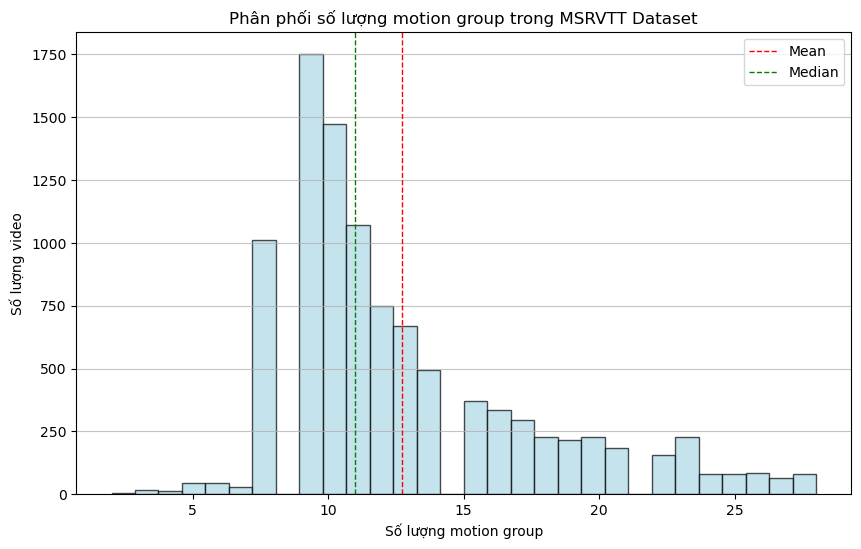

In [13]:
# Plot histogram of motion groups
plt.figure(figsize=(10, 6))
plt.hist(merged_df["motion_group"], bins=30, color='lightblue', alpha=0.7, edgecolor='black')
plt.axvline(merged_df["motion_group"].mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(merged_df["motion_group"].median(), color='green', linestyle='dashed', linewidth=1)
plt.legend({'Mean': merged_df["motion_group"].mean(), 'Median': merged_df["motion_group"].median()})
plt.title("Phân phối số lượng motion group trong MSRVTT Dataset")
plt.xlabel("Số lượng motion group")
plt.ylabel("Số lượng video")
plt.grid(axis='y', alpha=0.75)
plt.show()

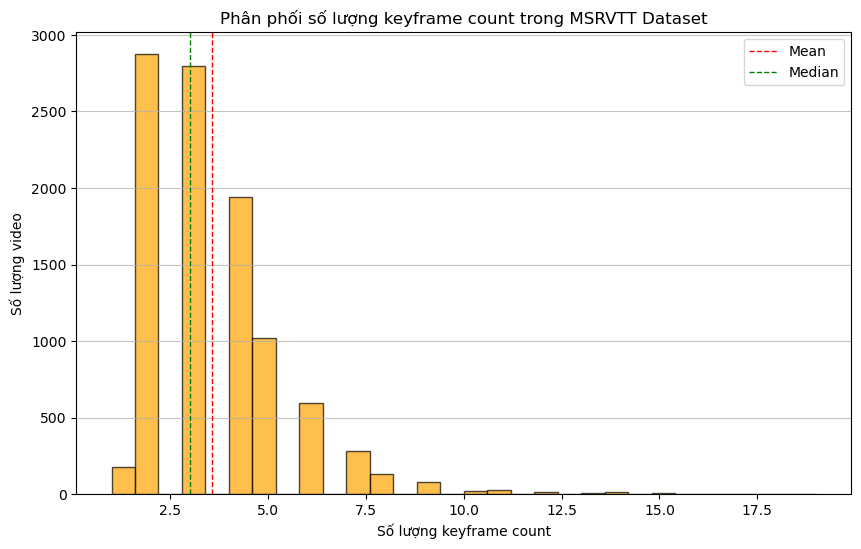

In [14]:
# Vẽ biểu đồ phân phối số lượng keyframe count
plt.figure(figsize=(10, 6))
plt.hist(merged_df["keyframe_count"], bins=30, color='orange', alpha=0.7, edgecolor='black')
plt.axvline(merged_df["keyframe_count"].mean(), color='red', linestyle='dashed', linewidth=1)
plt.axvline(merged_df["keyframe_count"].median(), color='green', linestyle='dashed', linewidth=1)
plt.legend({'Mean': merged_df["keyframe_count"].mean(),'Median': merged_df["keyframe_count"].median()})
plt.title("Phân phối số lượng keyframe count trong MSRVTT Dataset")
plt.xlabel("Số lượng keyframe count")
plt.ylabel("Số lượng video")
plt.grid(axis='y', alpha=0.75)
plt.show()